<a href="https://colab.research.google.com/github/SridharS-Square/Agentic_AI_Workshop/blob/main/Building%20Advanced%20Al%20Agents%20with%20LangGraph/Multi-Agent%20Research%20and%20Summarization%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install -q -U langchain langgraph langchain-google-genai beautifulsoup4 faiss-cpu tavily-python langchain_community pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.7/309.7 kB 16.3 MB/s eta 0:00:00


In [2]:
import os
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

In [3]:
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        keys: A dictionary to store the user query.
    """
    keys: dict

In [21]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Use a model that is good at tool calling
llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash-latest", temperature=0)

In [22]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# 1. Load the PDF
loader = PyPDFLoader("./samplPdf.pdf")
docs = loader.load()

# 2. Split the document into chunks
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs)

# 3. Create the vector store
vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=GoogleGenerativeAIEmbeddings(model="models/embedding-001")
)

# 4. Create the retriever
retriever = vectorstore.as_retriever()
print("Vector store for RAG is ready!")

Vector store for RAG is ready!


In [30]:
from langchain.tools.render import format_tool_to_openai_function
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field

class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""
    datasource: str = Field(
        ...,
        description="Given a user query, route it to the most relevant data source.",
        enum=["web_search", "rag", "llm"],
    )

# Create the router tool and bind it to the LLM
llm_with_router = llm.with_structured_output(RouteQuery)

# Define the router logic
def router(state):
    print("---ROUTING QUERY---")
    query = state['keys']['query']
    source = llm_with_router.invoke(query)
    print(f"Routing to: {source.datasource}")

    if source.datasource == 'web_search':
        print("---DECISION: ROUTE TO WEB SEARCH---")
        return {"web_search": None}
    elif source.datasource == 'rag':
        print("---DECISION: ROUTE TO RAG---")
        return {"rag": None}
    elif source.datasource == 'llm':
        print("---DECISION: ROUTE TO LLM---")
        return {"llm": None}

In [24]:
from langchain_community.tools.tavily_search import TavilySearchResults

# Add the key to the environment
os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')

# Create the tool
web_search_tool = TavilySearchResults()

def web_search(state):
    print("---PERFORMING WEB SEARCH---")
    query = state['keys']['query']
    search_results = web_search_tool.invoke({"query": query})
    return {"keys": {"query": query, "result": search_results}}

In [25]:
def rag(state):
    print("---PERFORMING RAG SEARCH---")
    query = state['keys']['query']
    retrieved_docs = retriever.invoke(query)
    return {"keys": {"query": query, "result": retrieved_docs}}

In [26]:
def llm_generate(state):
    print("---GENERATING LLM RESPONSE---")
    query = state['keys']['query']
    # You can add a prompt template here for more complex reasoning
    result = llm.invoke(query)
    return {"keys": {"query": query, "result": result.content}}

In [27]:
def summarize(state):
    print("---SUMMARIZING GATHERED INFORMATION---")
    query = state['keys']['query']
    gathered_data = state['keys']['result']

    prompt = f"""
    As a research assistant, your task is to provide a clear and structured answer to the user's query based on the provided information.

    User Query: {query}

    Collected Information:
    {gathered_data}

    Please synthesize this information and provide a final, well-structured answer.
    """
    summary = llm.invoke(prompt)
    return {"keys": {"query": query, "result": summary.content}}

In [32]:
from langgraph.graph import END, StateGraph

workflow = StateGraph(GraphState)

# Add the nodes
workflow.add_node("web_search", web_search)
workflow.add_node("rag", rag)
workflow.add_node("llm", llm_generate)
workflow.add_node("summarize", summarize)
workflow.add_node("router", router) # Add the router node

# Set the entry point and conditional edges
workflow.set_entry_point("router")
workflow.add_conditional_edges(
    "router",
    # The router function returns a dictionary like {"web_search": None}
    # We need to extract the key from this dictionary to determine the next node
    lambda state: list(state.keys())[0],
    {
        "web_search": "web_search",
        "rag": "rag",
        "llm": "llm",
    }
)

# Define the final connections
workflow.add_edge("web_search", "summarize")
workflow.add_edge("rag", "summarize")
workflow.add_edge("llm", END) # The LLM generator can end directly
workflow.add_edge("summarize", END)

# Compile the graph
app = workflow.compile()
print("LangGraph workflow compiled successfully!")

LangGraph workflow compiled successfully!


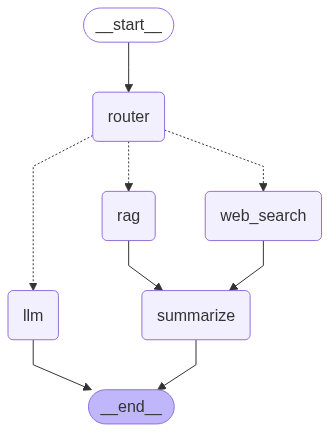

In [19]:
from IPython.display import Image

# This will generate a visual representation of your agent workflow
Image(app.get_graph().draw_mermaid_png())

In [33]:
# Test Query 1: RAG
query_rag = "What are the requirements for this assignment?"
output = app.invoke({"keys": {"query": query_rag}})
print("\n--- FINAL RESPONSE (RAG) ---\n")
print(output['keys']['result'])

# Test Query 2: Web Search
query_web = "What are the latest advancements in Google's Gemini models as of July 2025?"
output = app.invoke({"keys": {"query": query_web}})
print("\n--- FINAL RESPONSE (Web Search) ---\n")
print(output['keys']['result'])

# Test Query 3: LLM
query_llm = "Explain the concept of 'agentic AI' in simple terms."
output = app.invoke({"keys": {"query": query_llm}})
print("\n--- FINAL RESPONSE (LLM) ---\n")
print(output['keys']['result'])

---ROUTING QUERY---
Routing to: web_search
---DECISION: ROUTE TO WEB SEARCH---
---PERFORMING WEB SEARCH---
---SUMMARIZING GATHERED INFORMATION---

--- FINAL RESPONSE (RAG) ---

Assignment requirements vary depending on the institution, department, and instructor.  However, common elements typically include:

* **Main focus or topic:** The central theme or subject of the assignment.
* **Due date(s):**  The deadline(s) for submission, including potential deadlines for drafts or stages of the assignment.
* **Length:**  Specified minimum and maximum lengths, often expressed in word count or page number.
* **Type of research and sources:**  The kind of research required (e.g., primary, secondary) and acceptable sources (e.g., peer-reviewed articles, books).  Citation style may also be specified.
* **Style and format:**  Required formatting guidelines (e.g., MLA, APA, Chicago) and stylistic expectations.
* **Method of submission:** How the assignment should be submitted (e.g., online platfor